# Прогнозирование удовлетворенности клиентов - данные электронной коммерции
Набор данных из 100 тысяч заказов, сделанных между 2016 и 2018 годами.

In [20]:
# !pip install plotly
# !pip install yellowbrick
# !pip install --upgrade --force-reinstall setuptools
!pip install pandas

In [21]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

import numpy as np
from datetime import date, datetime, timedelta# as in python date is not a type of their own, we need import "python datetime module" to work with date, this module has classes like date, time, datetime, timedelta...
import pandas as pd # python library for data analysis 
import json # library to parse JSON
import matplotlib.pyplot as plt # library for creating visualizations
import plotly.graph_objects as go # library for creating interactive visualizations
import plotly.express as px # library for creating interactive visualizations
from plotly.subplots import make_subplots

from sklearn.cluster import KMeans # sklearn is a machine learning library
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

import ipywidgets as widgets

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)


In [70]:
# открытие данных
home_dir = 'C:/LinuxShared/магистратура/хакатон2/hackathon/'
customers_df= pd.read_csv(home_dir + 'customers.csv')
geolocation_df= pd.read_csv(home_dir + 'geolocation.csv')
items_df= pd.read_csv(home_dir + 'orders_items.csv')
payments_df= pd.read_csv(home_dir + 'order_payments.csv')
reviews_df= pd.read_csv(home_dir + 'order_reviews.csv')
orders_df= pd.read_csv(home_dir + 'orders.csv')
products_df= pd.read_csv(home_dir + 'products.csv')
sellers_df= pd.read_csv(home_dir + 'sellers.csv')
category_translation_df= pd.read_csv(home_dir + 'product_category_name_translation.csv')



C:\Users\днс\AppData\Local\Temp\ipykernel_21332\1926277062.py:5: DtypeWarning:

Columns (1,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.



In [71]:
df= pd.merge(customers_df, orders_df, on="customer_id", how='inner')
df= df.merge(reviews_df, on="order_id", how='inner')
df= df.merge(items_df, on="order_id", how='inner')
df= df.merge(products_df, on="product_id", how='inner')
df= df.merge(payments_df, on="order_id", how='inner')
display(df.head())


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,Unnamed: 0,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,8683.0,54.0,64.0,31.0,19778,1,credit_card,2,146.87
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,8683.0,54.0,64.0,31.0,123664,1,credit_card,2,146.87
2,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,8683.0,54.0,64.0,31.0,227550,1,credit_card,2,146.87
3,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,3.0,10150.0,89.0,15.0,40.0,33639,1,credit_card,8,335.48
4,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,3.0,10150.0,89.0,15.0,40.0,137525,1,credit_card,8,335.48


In [ ]:
display(items_df.head())


,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,18.14


In [72]:
cluster_df = orders_df.copy()
cluster_df = cluster_df.merge(reviews_df, on="order_id", how='inner')
cluster_df = cluster_df.merge(items_df, on="order_id", how='inner')
display(cluster_df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Unnamed: 0_x,review_id,...,Unnamed: 0_y,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,32790,a54f0611adc9ed256b57ede6b6eb5114,...,100785,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,29158,8d5266042046a06655c8db133d120ba5,...,36896,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,4323,e73b67b67587f7644d5bd1a52deb1b01,...,31504,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,77520,359d03e676b3c069f62cadba8dd3f6e8,...,65021,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,54136,e50934924e227544ba8246aeb3770dd4,...,76043,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02-19 20:31:37,19.90,8.72


In [26]:
cluster_df.columns



Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'Unnamed: 0_x', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'Unnamed: 0_y', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'shipping_limit_date.1', 'price.1', 'freight_value.1'],
      dtype='object')

In [73]:
cluster_df.drop(columns=['order_status','Unnamed: 0_x','Unnamed: 0_y','price.1','freight_value.1','seller_id','review_comment_message'], inplace=True)

In [75]:
import pandas as pd
from datetime import timedelta

# Преобразование строк в даты
cluster_df['order_estimated_delivery_date'] = pd.to_datetime(cluster_df['order_estimated_delivery_date'])
cluster_df['order_delivered_customer_date'] = pd.to_datetime(cluster_df['order_delivered_customer_date'])

# Нахождение разницы в днях
cluster_df['day_difference'] = (
    cluster_df['order_delivered_customer_date'] - cluster_df['order_estimated_delivery_date']
).dt.days

# Округление разницы в днях (если необходимо)
cluster_df['rounded_delivered_difference'] = cluster_df['day_difference'].round()

# Показать результат
print(cluster_df.rounded_delivered_difference)

0         -8.0
1         -6.0
2        -18.0
3        -13.0
4        -10.0
          ... 
112367    -2.0
112368    -6.0
112369   -21.0
112370   -21.0
112371   -18.0
Name: rounded_delivered_difference, Length: 112372, dtype: float64


In [76]:
print(cluster_df['review_answer_timestamp'])
print(cluster_df['review_creation_date'])

0         2017-10-12 03:43:48
1         2018-08-08 18:37:50
2         2018-08-22 19:07:58
3         2017-12-05 19:21:58
4         2018-02-18 13:02:51
                 ...         
112367    2018-03-02 17:50:01
112368    2017-09-22 23:10:57
112369    2018-01-27 09:16:56
112370    2018-01-27 09:16:56
112371    2018-03-17 16:33:31
Name: review_answer_timestamp, Length: 112372, dtype: object
0         2017-10-11 00:00:00
1         2018-08-08 00:00:00
2         2018-08-18 00:00:00
3         2017-12-03 00:00:00
4         2018-02-17 00:00:00
                 ...         
112367    2018-03-01 00:00:00
112368    2017-09-22 00:00:00
112369    2018-01-26 00:00:00
112370    2018-01-26 00:00:00
112371    2018-03-17 00:00:00
Name: review_creation_date, Length: 112372, dtype: object


In [77]:
cluster_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112372 non-null  object        
 1   customer_id                    112372 non-null  object        
 2   order_purchase_timestamp       112372 non-null  object        
 3   order_approved_at              112357 non-null  object        
 4   order_delivered_carrier_date   111188 non-null  object        
 5   order_delivered_customer_date  110012 non-null  datetime64[ns]
 6   order_estimated_delivery_date  112372 non-null  datetime64[ns]
 7   review_id                      112372 non-null  object        
 8   review_score                   112372 non-null  int64         
 9   review_comment_title           13434 non-null   object        
 10  review_creation_date           112372 non-null  object        
 11  

In [78]:
import pandas as pd

# Преобразование строк в даты с принудительным преобразованием ошибок в NaT
cluster_df['review_answer_timestamp'] = pd.to_datetime(cluster_df['review_answer_timestamp'], errors='coerce')
cluster_df['review_creation_date'] = pd.to_datetime(cluster_df['review_creation_date'], errors='coerce')

# Нахождение разницы в днях
cluster_df['review_difference'] = (
    cluster_df['review_answer_timestamp'] - cluster_df['review_creation_date']
).dt.days

# Удаление строк с NaT (если нужно)
cluster_df.dropna(subset=['review_difference'], inplace=True)

# Округление разницы в днях (если необходимо)
cluster_df['rounded_review_difference'] = cluster_df['review_difference'].round()

# Показать результат
print(cluster_df.rounded_review_difference)

0         1
1         0
2         4
3         2
4         1
         ..
112367    1
112368    0
112369    1
112370    1
112371    0
Name: rounded_review_difference, Length: 112372, dtype: int64


In [79]:
cluster_df.drop(columns=['day_difference','shipping_limit_date','order_estimated_delivery_date','order_delivered_customer_date','review_difference','review_answer_timestamp','review_creation_date'], inplace=True)
cluster_df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date', 'review_id',
       'review_score', 'review_comment_title', 'order_item_id', 'product_id',
       'price', 'freight_value', 'shipping_limit_date.1',
       'rounded_delivered_difference', 'rounded_review_difference'],
      dtype='object')

In [80]:
cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   order_id                      112372 non-null  object 
 1   customer_id                   112372 non-null  object 
 2   order_purchase_timestamp      112372 non-null  object 
 3   order_approved_at             112357 non-null  object 
 4   order_delivered_carrier_date  111188 non-null  object 
 5   review_id                     112372 non-null  object 
 6   review_score                  112372 non-null  int64  
 7   review_comment_title          13434 non-null   object 
 8   order_item_id                 112372 non-null  float64
 9   product_id                    112372 non-null  object 
 10  price                         112372 non-null  float64
 11  freight_value                 112372 non-null  float64
 12  shipping_limit_date.1         112372 non-nul

In [81]:
cluster_df_tmp = cluster_df[['rounded_review_difference','rounded_delivered_difference','freight_value','order_id']]
cluster_df_tmp.head()

,rounded_review_difference,rounded_delivered_difference,freight_value,order_id
0,1,-8.0,8.72,e481f51cbdc54678b7cc49136f2d6af7
1,0,-6.0,22.76,53cdb2fc8bc7dce0b6741e2150273451
2,4,-18.0,19.22,47770eb9100c2d0c44946d9cf07ec65d
3,2,-13.0,27.20,949d5b44dbf5de918fe9c16f97b45f8a
4,1,-10.0,8.72,ad21c59c0840e6cb83a9ceb5573f8159


In [88]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def normalize_dataframe(df, columns):
    """
    Создает новый датафрейм с указанными колонками, заполняет пропуски нулевыми значениями и нормализует данные.
    
    Аргументы:
    df: Датафрейм Pandas
    columns: Список названий колонок для включения в новый датафрейм
    
    Возвращает:
    Новый датафрейм с нормализованными данными
    """
    # Создаем новый датафрейм с указанными колонками
    new_df = df[columns + ['order_id']]
    
    # Заполняем пропуски нулевыми значениями
    new_df.fillna(0, inplace=True)
    
    # Нормализация данных
    scaler = MinMaxScaler()
    normalized_columns = [col for col in columns if col != 'order_id']
    normalized_df = pd.DataFrame(scaler.fit_transform(new_df[normalized_columns]), columns=normalized_columns)
    
    # Добавляем колонку order_id обратно в нормализованный датафрейм
    normalized_df['order_id'] = new_df['order_id']
    
    return normalized_df

# Пример использования функции
normalized_df = normalize_dataframe(
    cluster_df,
    ['rounded_delivered_difference', 'rounded_review_difference', 'freight_value'],
)

# Показать результат
print(normalized_df)

# Преобразование типа данных только для числовых колонок
numeric_columns = ['rounded_delivered_difference', 'rounded_review_difference', 'freight_value']
normalized_df[numeric_columns] = normalized_df[numeric_columns].astype('float16')

        rounded_delivered_difference  rounded_review_difference  \
0                           0.414925                   0.001931   
1                           0.420896                   0.000000   
2                           0.385075                   0.007722   
3                           0.400000                   0.003861   
4                           0.408955                   0.001931   
...                              ...                        ...   
112367                      0.432836                   0.001931   
112368                      0.420896                   0.000000   
112369                      0.376119                   0.001931   
112370                      0.376119                   0.001931   
112371                      0.385075                   0.000000   

        freight_value                          order_id  
0            0.021285  e481f51cbdc54678b7cc49136f2d6af7  
1            0.055556  53cdb2fc8bc7dce0b6741e2150273451  
2            0.046915

C:\Users\днс\AppData\Local\Temp\ipykernel_21332\243708761.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [43]:
half_df = normalized_df.sample(frac=0.5)

dbscan_1 = DBSCAN(eps=0.5, metric='euclidean', min_samples=1000, n_jobs=-1)
dbscan_1.fit(half_df)

unique, counts = np.unique(dbscan_1.labels_, return_counts=True)
print(np.asarray((unique, counts)).T)

[[    0 56186]]


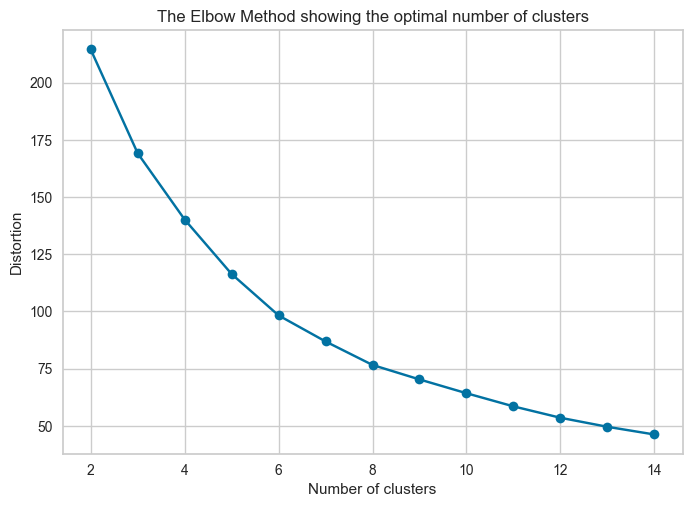

In [92]:
# k-means
distortions = []
for i in range(2, 15):
    kmodel = KMeans(n_clusters=i,
                    n_init=1000,  # run 5 times with different random initial centroids to avoid suboptimal solutions
                    random_state=1)
    kmodel.fit(normalized_df[['rounded_delivered_difference', 'rounded_review_difference', 'freight_value']])
    distortions.append(kmodel.inertia_)  # KMeans inertia = Sum of Squares Errors (SSE)

plt.plot(range(2, 15), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal number of clusters')
plt.show()

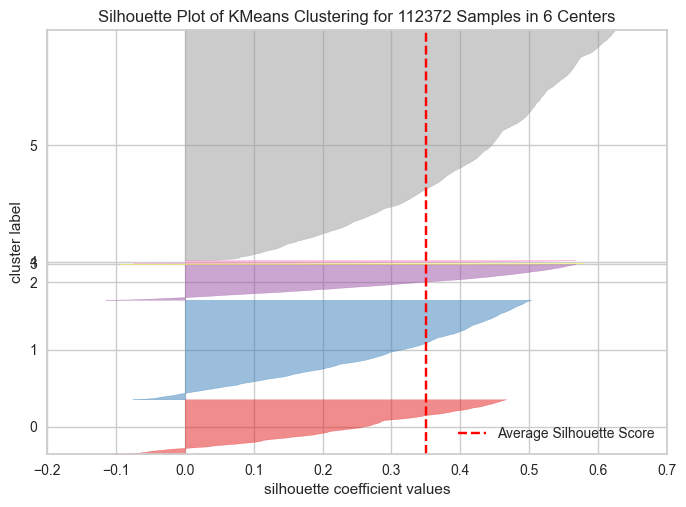

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 112372 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [50]:
vis=SilhouetteVisualizer(KMeans(n_clusters=6,n_init=5, random_state=1))
vis.fit(normalized_df)
vis.show()

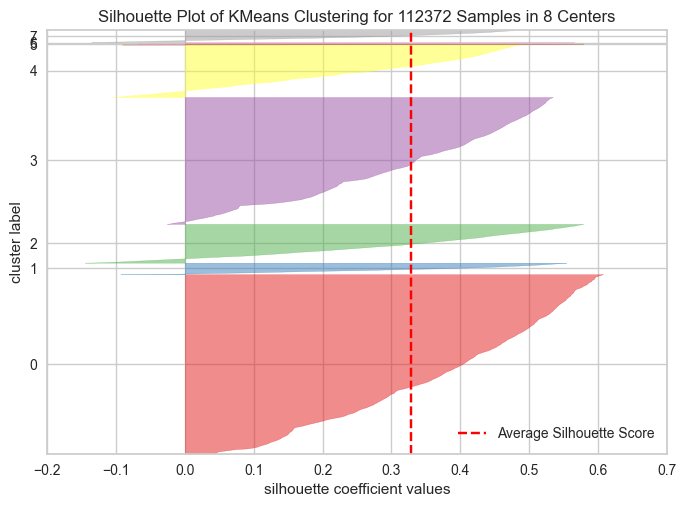

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 112372 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [60]:
vis_8 =SilhouetteVisualizer(KMeans(n_clusters=8,n_init=1000, random_state=1))
vis_8.fit(normalized_df)
vis_8.show()

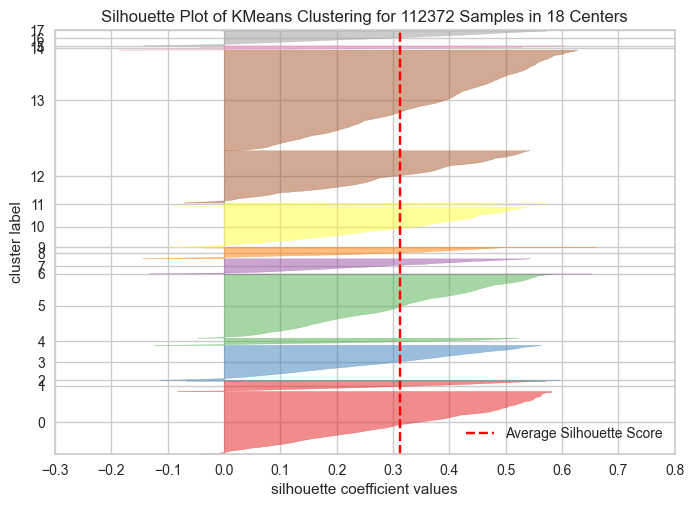

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 112372 Samples in 18 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
vis=SilhouetteVisualizer(KMeans(n_clusters=18,n_init=1000, random_state=1))
vis.fit(normalized_df)
vis.show()

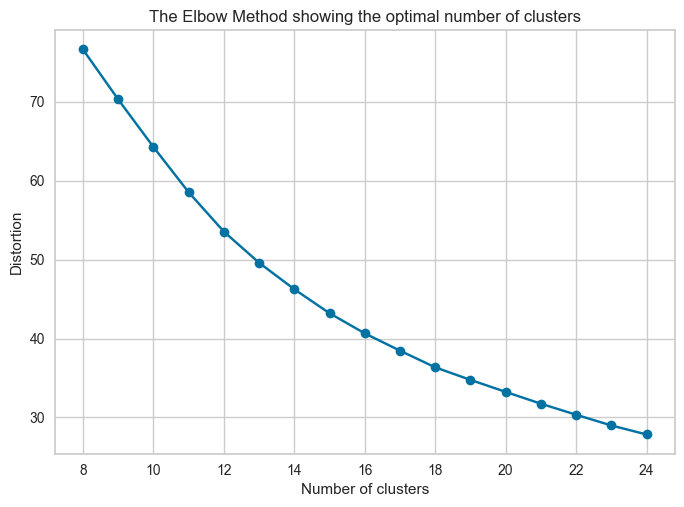

In [56]:
# k-means
distortions=[]
for i in range(8,25):
    kmodel=KMeans(n_clusters=i,
                 n_init=200, # run N times with different random inicial centroids to avoid suboptimal solutions
                 random_state=1)
    kmodel.fit(normalized_df)
    distortions.append(kmodel.inertia_) # KMeans inertia = Sum of Squares Errors (SSE)
    
plt.plot(range(8,25), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal number of clusters')
plt.show()

In [96]:
# Кластеризация с помощью K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=1000).fit(normalized_df[['rounded_delivered_difference', 'rounded_review_difference', 'freight_value']])

# Добавление меток кластеров в нормализованный датафрейм
normalized_df['cluster_label'] = kmeans.labels_

# Связываем метки кластеров с исходным датафреймом по order_id
cluster_df = cluster_df.merge(normalized_df[['order_id', 'cluster_label']], on='order_id', how='left')

# Просмотр результата
print(cluster_df)

                                order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
158611  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
158612  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
158613  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
158614  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
158615  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_purchase_timestamp    order_approved_at  \
0      

In [98]:
cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   order_id                      158616 non-null  object 
 1   customer_id                   158616 non-null  object 
 2   order_purchase_timestamp      158616 non-null  object 
 3   order_approved_at             158599 non-null  object 
 4   order_delivered_carrier_date  156730 non-null  object 
 5   review_id                     158616 non-null  object 
 6   review_score                  158616 non-null  int64  
 7   review_comment_title          19774 non-null   object 
 8   order_item_id                 158616 non-null  float64
 9   product_id                    158616 non-null  object 
 10  price                         158616 non-null  float64
 11  freight_value                 158616 non-null  float64
 12  shipping_limit_date.1         158616 non-nul

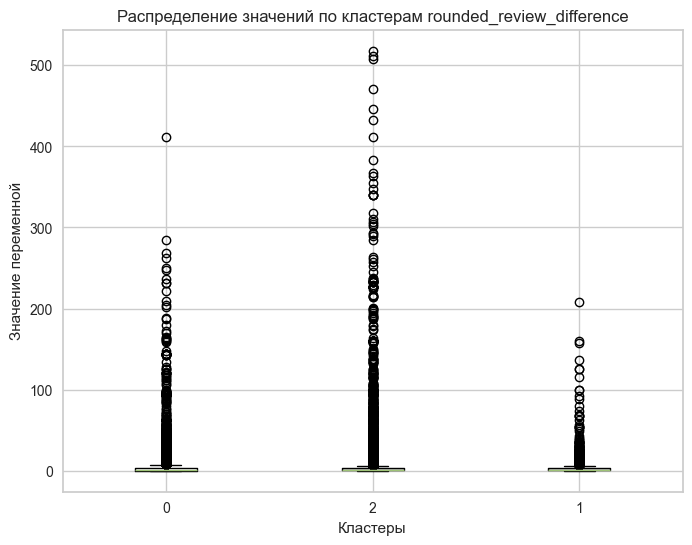

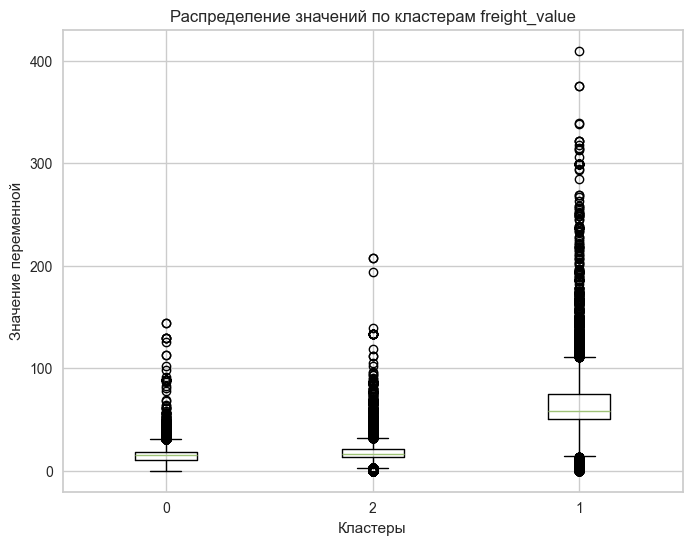

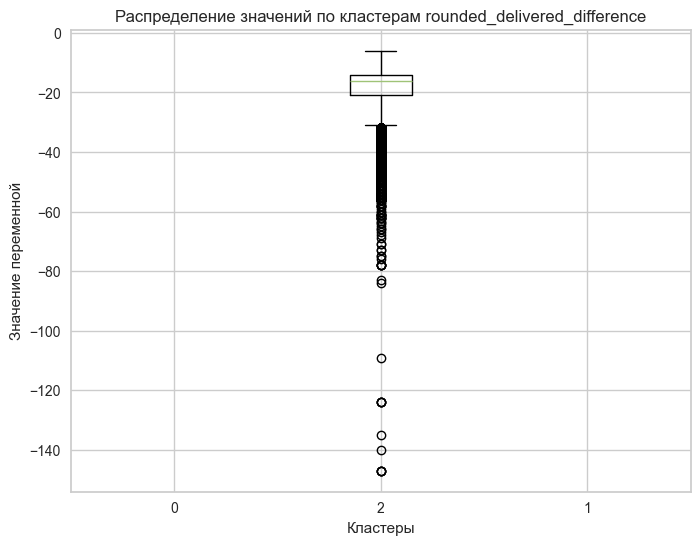

In [99]:
import matplotlib.pyplot as plt

# Получаем уникальные метки кластеров
clusters = cluster_df['cluster_label'].unique()

for column_name in ['rounded_review_difference', 'freight_value', 'rounded_delivered_difference']:
    # Формируем списки данных для каждого кластера
    data_by_cluster = {label: cluster_df.loc[cluster_df['cluster_label'] == label][column_name] for label in clusters}

    # Строим диаграмму "ящик с усами"
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.boxplot([data for data in data_by_cluster.values()])
    ax.set_xticklabels(clusters)
    ax.set_xlabel('Кластеры')
    ax.set_ylabel('Значение переменной')
    plt.title(f'Распределение значений по кластерам {column_name}')
    plt.show()

In [101]:
# Вычисляем медианы по указанным колонкам в разрезе кластеров
median_table = cluster_df.groupby('cluster_label')[['rounded_review_difference', 'freight_value', 'rounded_delivered_difference']].median().reset_index()

# Выводим таблицу с медианами
print(median_table)

   cluster_label  rounded_review_difference  freight_value  \
0              0                        1.0          14.98   
1              1                        1.0          58.66   
2              2                        1.0          16.74   

   rounded_delivered_difference  
0                          -7.0  
1                         -13.0  
2                         -16.0  


Найдем периоды между заказами